In [ ]:
#find data for bootstarmping method of age
import numpy as np
import multiprocessing as mp
from scipy.integrate import odeint
from scipy.optimize import differential_evolution
import pandas as pd
def replace_nan_with_average(series):
    # Identify the indices of NaN values
    nan_indices = np.where(np.isnan(series))[0]
    
    for idx in nan_indices:
        print("yes")
        # Ensure there are previous and next values to average
        if idx > 0 and idx < len(series) - 1:
            previous_value = series[idx - 1]
            next_value = series[idx + 1]
            if not np.isnan(previous_value) and not np.isnan(next_value):
                series[idx] = (previous_value + next_value) / 2.0
            elif not np.isnan(previous_value):
                series[idx] = previous_value
            elif not np.isnan(next_value):
                series[idx] = next_value
    return series
def model (data,time, α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3): 
    A1,R1,V1,A2,R2,V2,A3,R3,V3=data
    dA1dt=-1*(α1+γ1*V1)*(A1-A_b1)+(β11*(A1+V1)+β21*(A2+V2)+β31*(A3+V3))*(R1-R_b1)
    dR1dt=-(β11*(A1+V1)+β21*(A2+V2)+β31*(A3+V3))*(R1-R_b1)
    dV1dt=(α1+γ1*V1)*(A1-A_b1)
    dA2dt=-1*(α2+γ2*V2)*(A2-A_b2)+(β12*(A1+V1)+β22*(A2+V2)+β32*(A3+V3))*(R2-R_b2)
    dR2dt=-(β12*(A1+V1)+β22*(A2+V2)+β32*(A3+V3))*(R2-R_b2)
    dV2dt=(α2+γ2*V2)*(A2-A_b2)
    dA3dt=-1*(α3+γ3*V3)*(A3-A_b3)+(β13*(A1+V1)+β23*(A2+V2)+β33*(A3+V3))*(R3-R_b3)
    dR3dt=-(β13*(A1+V1)+β23*(A2+V2)+β33*(A3+V3))*(R3-R_b3)
    dV3dt=(α3+γ3*V3)*(A3-A_b3)
    return [dA1dt,dR1dt,dV1dt,dA2dt,dR2dt,dV2dt,dA3dt,dR3dt,dV3dt]
def loss(parameters, data_0, time, data): 
    α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3= parameters
    data_predict = odeint(model, data_0, time, args=(α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3))
    A1_predict = data_predict[:, 0]
    R1_predict = data_predict[:, 1]
    V1_predict = data_predict[:, 2]
    A2_predict = data_predict[:, 3]
    R2_predict = data_predict[:, 4]
    V2_predict = data_predict[:, 5]
    A3_predict = data_predict[:, 6]
    R3_predict = data_predict[:, 7]
    V3_predict = data_predict[:, 8]
    return np.sum((A1_predict - data[0,:]) ** 2+(R1_predict - data[1,:]) ** 2+(V1_predict - data[2,:]) ** 2+(A2_predict - data[3,:]) ** 2+(R2_predict - data[4,:]) ** 2+(V2_predict - data[5,:]) ** 2+(A3_predict - data[6,:]) ** 2+(R3_predict - data[7,:]) ** 2+(V3_predict - data[8,:]) ** 2)
statelist=["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"]
def funcc(mmmm):
    print(mmmm)
    df3=pd.read_csv("parameter.csv")
    data_0=np.zeros([9])
    xd=np.zeros([9,536])
    rr=0
    while rr<5:
        i=np.random.randint(0,len(statelist))
        state=statelist[i]
        if df3["Politic"].iloc[i]=="R":   #You can change it by D for democrate or always tru for national 
            df = pd.read_csv(state+'.csv')
            df2=df.drop(columns="Dates")
            dataa=df2.to_numpy().T
            xd+=dataa/np.sum(dataa,axis=0)
            rr+=1
            time=np.arange(0, len(df['Dates']), 1)
    xd=xd/5
    for i in range(9):
        xd[i,:]=replace_nan_with_average(xd[i,:])
    data_0=list(xd[:,0])
    Bounds=((0,1),(0,1),(0,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1)) 
    result = differential_evolution(loss, bounds=Bounds,args=(data_0, time,xd))
    best_params = result.x
    np.savetxt(f"{mmmm}.txt",best_params)
def main():
    pool=mp.Pool(mp.cpu_count())
    results=pool.map(funcc,list(np.arange(0,5000,1)))
main()


In [ ]:
import numpy as np
data=np.zeros([21,5000])
for i in range(5000):
    tit=f"/Republic/{i}.txt"  #address of the micro data from bootmethod  (change it for R,D,N)
    w=np.loadtxt(tit)
    data[:,i]=w
np.savetxt("edu,model2,republican.txt",data)

In [4]:
#You can make your data or use our data
import numpy as np
dataN=np.loadtxt("edu,model2,national.txt")
dataR=np.loadtxt("edu,model2,R.txt")
dataD=np.loadtxt("edu,model2,D.txt")

/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataN[i], shade=True, color="green",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataR[i], shade=True, color="blue",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataD[i], shade=True, color="red",bw_adjust=2,ax=ax,

0
1
2
3
4
5


/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataR[i], shade=True, color="blue",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataD[i], shade=True, color="red",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataN[i], shade=True, color="green",bw_adjust=2,ax=ax,

6
7
8
9
10
11


/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataD[i], shade=True, color="red",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataN[i], shade=True, color="green",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataR[i], shade=True, color="blue",bw_adjust=2,ax=ax,

12
13
15
16


/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataN[i], shade=True, color="green",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:23: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataR[i], shade=True, color="blue",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_39440/2753490110.py:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dataD[i], shade=True, color="red",bw_adjust=2,ax=ax,

18
19


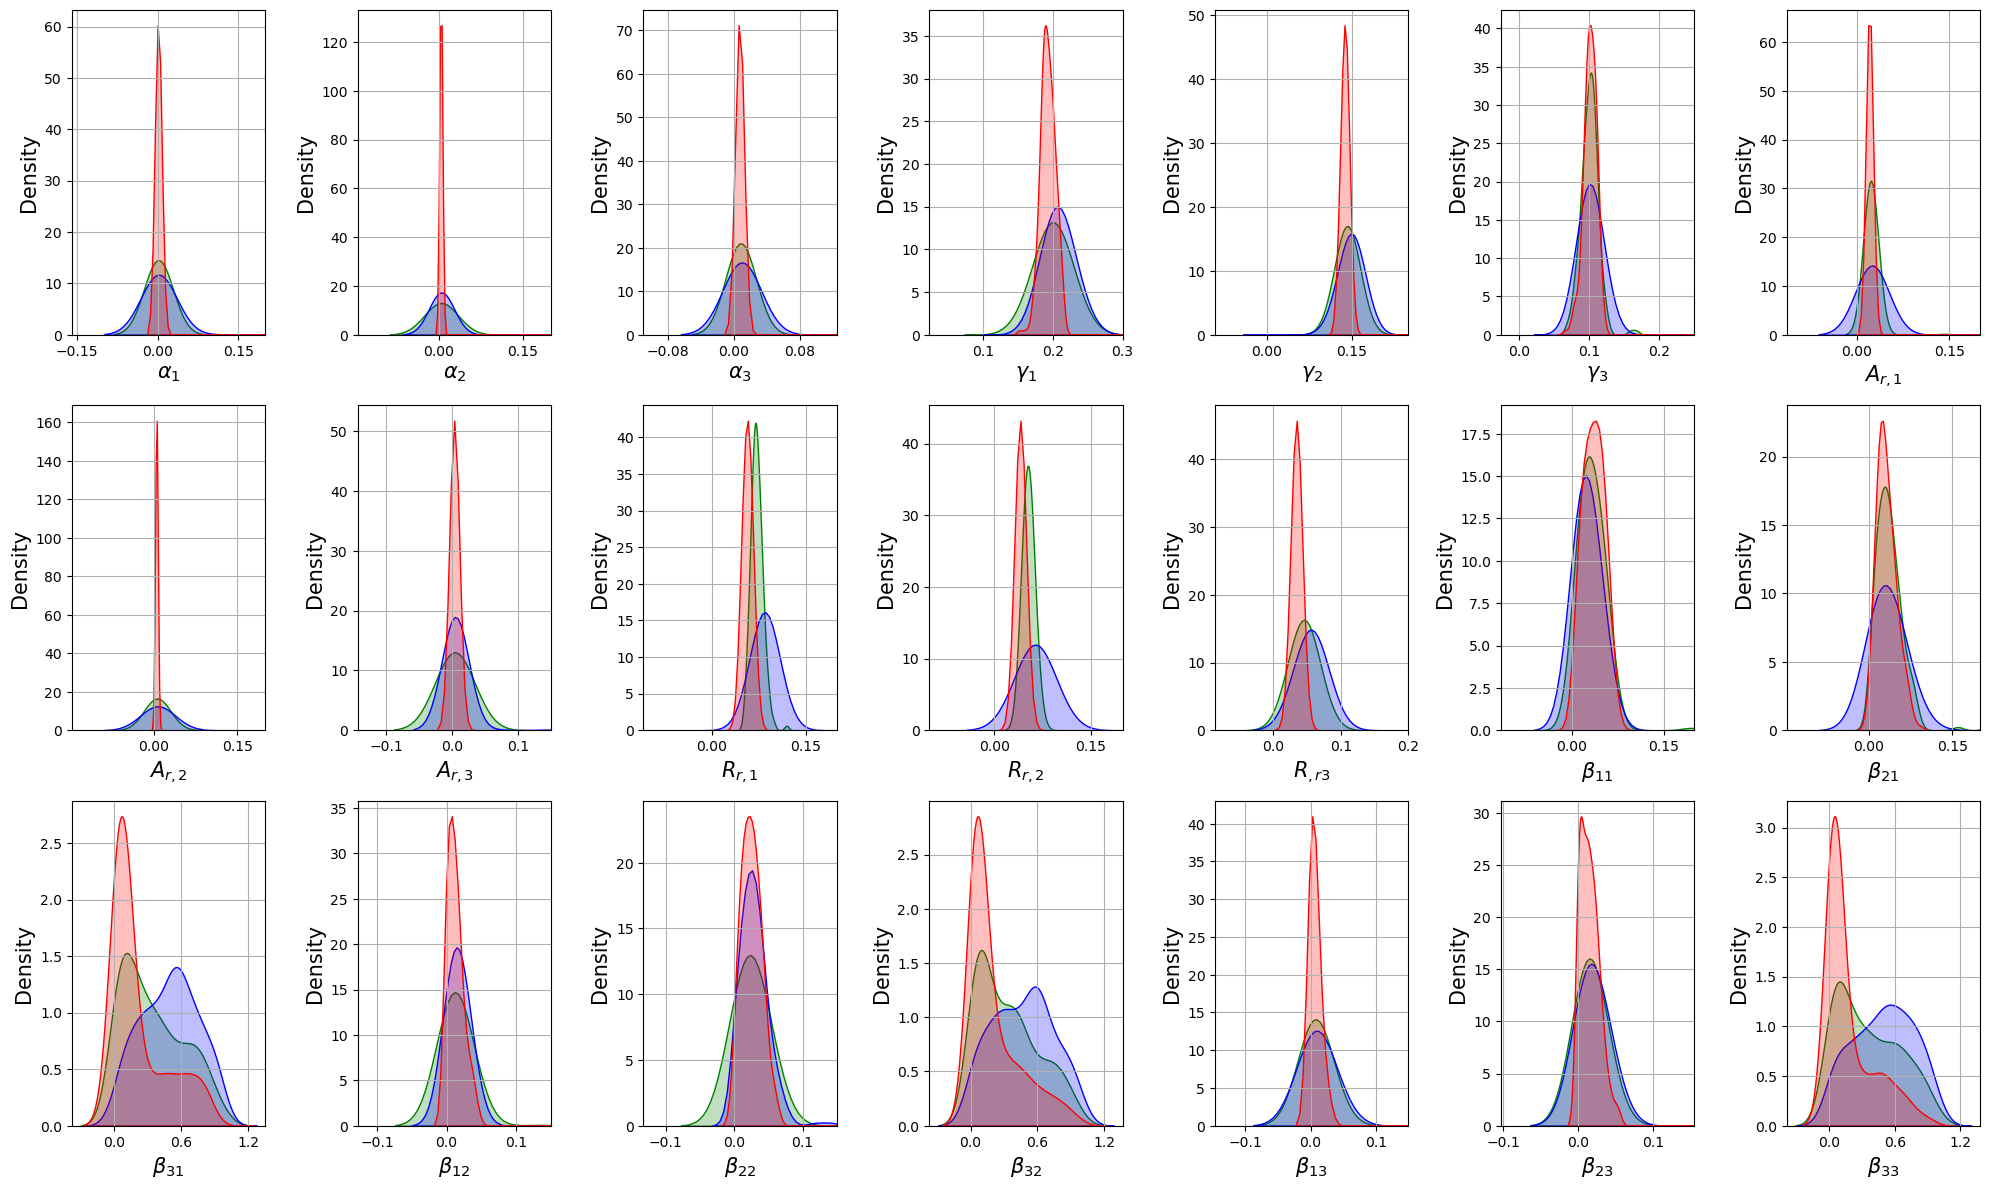

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from matplotlib.ticker import MaxNLocator
# Generate 15 random datasets for demonstration


# Set up the figure and axes for the subplots
fig, axes = plt.subplots(3, 7, figsize=(20, 12))
axes = axes.flatten()


labels = [r"$\alpha_1$",r"$\alpha_2$",r"$\alpha_3$",r"$\gamma_1$",r"$\gamma_2$",r"$\gamma_3$",r"$A_{r,1}$",r"$A_{r,2}$",r"$A_{r,3}$",
       r"$R_{r,1}$",r"$R_{r,2}$",r"$R_{,r3}$",r"$\beta_{11}$",r"$\beta_{21}$",r"$\beta_{31}$",
       r"$\beta_{12}$",r"$\beta_{22}$",r"$\beta_{32}$",r"$\beta_{13}$",r"$\beta_{23}$",r"$\beta_{33}$"]
ilist=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19]
xlimm=[0.2,0.2,0.125,0.3,0.25,0.25,0.2,0.2,0.15,0.2,0.2,0.2,0.2,0.2,0.15,0.15,0.15,0.155]
j=0
# Plot each dataset in its own subplot
for i, ax in enumerate(axes):
    sns.kdeplot(dataN[i], shade=True, color="green",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
    sns.kdeplot(dataR[i], shade=True, color="blue",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
    sns.kdeplot(dataD[i], shade=True, color="red",bw_adjust=2,ax=ax,common_norm=True,clip=(-np.inf, np.inf))
    statistic, p_value = ttest_ind(dataR[i], dataD[i])
    ax.set_xlabel(f'{labels[i]}',fontsize=15)
    ax.set_ylabel(f'Density',fontsize=15)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    if i in ilist:
        print(i)
        ax.set_xlim(left=None,right=xlimm[j])
        j+=1
    #ax.legend()
    #ax.set_title(f'p_value= {p_value}')
    ax.grid(True)
    ax.tick_params(axis='x', labelsize=10)  # Set fontsize for x-ticks
    ax.tick_params(axis='y', labelsize=10) 

# Adjust layout for better spacing between plots
plt.tight_layout()
plt.savefig("edu_Boostrap_distribution.jpg",dpi=500)
# Show the plot
plt.show()


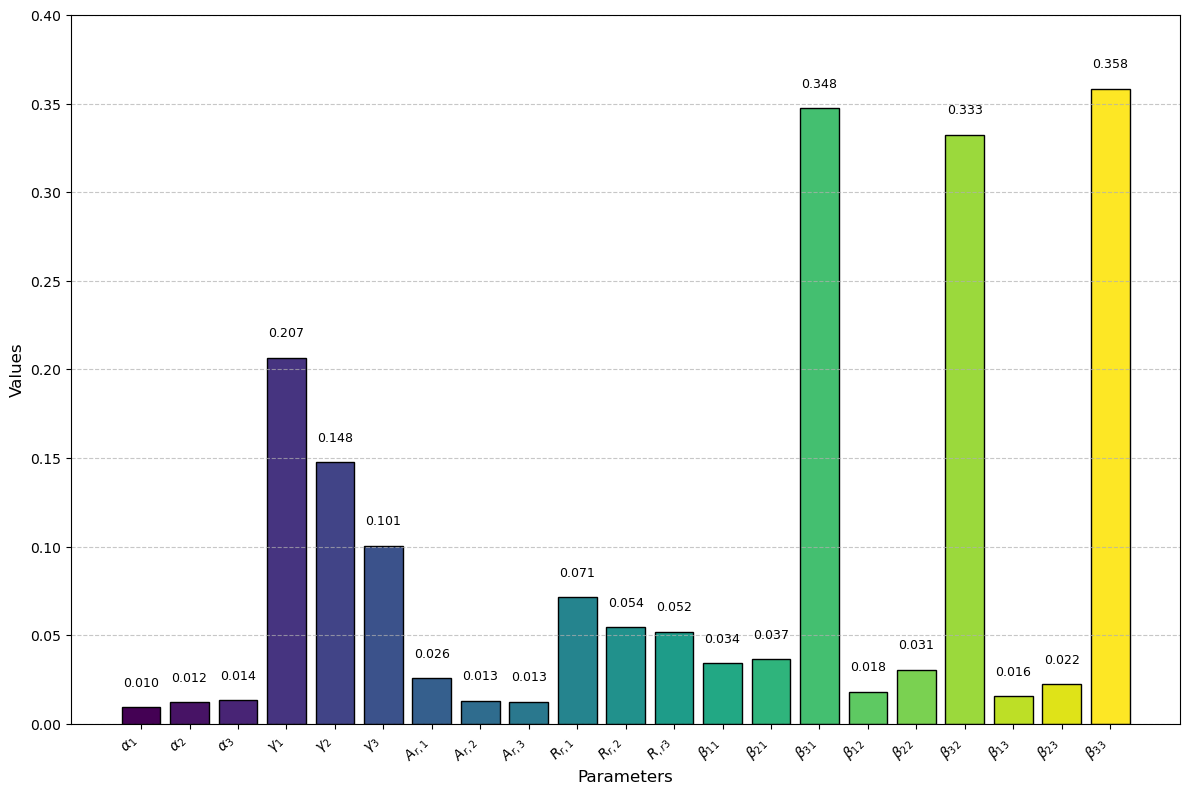

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
# Replace 'data' with your actual dataset
np.random.seed(42)  # For reproducibility of the example # Example dataset
labels = [r"$\alpha_1$",r"$\alpha_2$",r"$\alpha_3$",r"$\gamma_1$",r"$\gamma_2$",r"$\gamma_3$",r"$A_{r,1}$",r"$A_{r,2}$",r"$A_{r,3}$",
       r"$R_{r,1}$",r"$R_{r,2}$",r"$R_{,r3}$",r"$\beta_{11}$",r"$\beta_{21}$",r"$\beta_{31}$",
       r"$\beta_{12}$",r"$\beta_{22}$",r"$\beta_{32}$",r"$\beta_{13}$",r"$\beta_{23}$",r"$\beta_{33}$"]
values = np.average(dataN, axis=1)  # Heights of the bars

# Create the bar chart
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(values)))  # Use a color map
bars = plt.bar(labels, values, color=colors, edgecolor="black")

# Add value annotations on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, height + 0.01,  # Adjust height offset
        f'{height:.3f}', ha='center', va='bottom', fontsize=9
    )

# Enhance the appearance
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels for readability
plt.yticks(fontsize=10)
plt.xlabel('Parameters', fontsize=12)
plt.ylabel('Values', fontsize=12)
#plt.title('edu', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for readability
plt.tight_layout() 
plt.ylim(0,0.4)# Adjust layout
plt.savefig("edu_Boostrap_cross_average.jpg", bbox_inches='tight',dpi=500)
# Show the plot
plt.show()
